In [1]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame
import scipy
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from datetime import datetime
import statsmodels.api as sm
import datetime
import sklearn
import os
import requests
import warnings
import pathlib

def find_npy_files(root_dir="."):
    """
    Recursively searches the given directory and all its subdirectories 
    for files ending with the '.npy' extension.

    Args:
        root_dir (str): The starting directory for the search. Defaults to the current directory.

    Returns:
        list: A list of absolute paths to all found .npy files.
    """
    root = pathlib.Path(root_dir)
    
    # rglob searches recursively ('r') for files matching '*.npy'
    npy_files = list(root.rglob('*.npy'))
    
    print(f"Found {len(npy_files)} .npy files starting from: {root.resolve()}")
    return npy_files

# --- Example Usage ---

# Search in the current directory ('.')
found_files = find_npy_files()

if found_files:
    print("\n--- List of Found Files ---")
    for file_path in found_files:
        print(file_path)
else:
    print("\nNo .npy files found in the current directory or its subfolders.")

Found 2193 .npy files starting from: C:\Users\Administrator\Desktop\compneuro\steinmetz

--- List of Found Files ---
.venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py27_np16.pkl_01.npy
.venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py27_np16.pkl_02.npy
.venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py27_np16.pkl_03.npy
.venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py27_np16.pkl_04.npy
.venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py27_np17.pkl_01.npy
.venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py27_np17.pkl_02.npy
.venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py27_np17.pkl_03.npy
.venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py27_np17.pkl_04.npy
.venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py33_np18.pkl_01.npy
.venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py33_np18.pkl_02.npy
.venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py

In [2]:
import pandas as pd
import numpy as np
import re
from pathlib import Path

# --- CONFIGURATION SECTION (CRITICAL: CUSTOMIZE THESE PATTERNS) ---
CATEGORY_PATTERNS = {
    # Category 1: Grouping by the main Experiment ID (The long prefix)
    "Experiment_9974357": r"^Steinmetz_et_al_2019_9974357.*\.npy$",
    
    # Category 2: Spike Data (Files containing 'spikes')
    "Spike_Data": r".*spikes.*\.npy$",
    
    # Category 3: Trial/Behavior Metrics (Files starting with 'trials.')
    "Trial_Metrics": r"^trials\..*\.npy$",
    
    # Category 4: Position/Site Data (Files containing 'sitePositions' or 'probes')
    "Position_Data": r".*sitePositions.*\.npy$",

    # Category 5: Time/Timestamp Data (Files containing '.timestamps.')
    "Timestamp_Data": r".*\.timestamps\.npy$",
}


def create_file_index_dataframe(root_dir=".") -> pd.DataFrame:
    """
    Recursively scans a directory, assigns multiple categories to each NPY file 
    based on defined regex patterns, and returns a master Pandas DataFrame index.

    Args:
        root_dir (str): The starting directory for the search. Defaults to the current directory.

    Returns:
        pd.DataFrame: A DataFrame where each row is an NPY file path with assigned categories.
    """
    print("Starting comprehensive file indexing...")
    
    master_index = []
    root = Path(root_dir)

    # 1. Find ALL .npy files first to avoid redundant regex checks
    all_npy_files = list(root.rglob('*.npy'))
    print(f"Found {len(all_npy_files)} total .npy files.")

    for file_path in all_npy_files:
        file_name = file_path.name

        # 2. Build a row with boolean flags for each category
        row = {
            "File_Path": str(file_path.resolve()),
            "Filename": file_name
        }
        for category, pattern in CATEGORY_PATTERNS.items():
            row[category] = bool(re.match(pattern, file_name))

        master_index.append(row)

    print("\nIndexing complete.")
    return pd.DataFrame(master_index)

# --- MAIN EXECUTION ---
if __name__ == "__main__":
    
    # 1. GENERATE THE INDEX TABLE (This runs once)
    file_index_df = create_file_index_dataframe()
    
    if not file_index_df.empty:
        print("\n" + "="*70)
        print("MASTER FILE INDEX DATAFRAME PREVIEW")
        print("="*70)
        print(file_index_df.head(10)) # Show the first 10 entries
        print(f"\nTotal indexed files: {len(file_index_df)}")

        # 2. HOW TO USE THE INDEX LATER (Example of targeted loading)
        
        # Example A: Find all spike data files
        spike_files_df = file_index_df[file_index_df['Spike_Data']]
        print("\n--- Targeted Search: Spike Data Files ---")
        print(f"Found {len(spike_files_df)} spike files.")
        if not spike_files_df.empty:
            print(spike_files_df[['Filename', 'File_Path']])

        # Example B: Find all trial metrics for Experiment 9974357
        trial_metrics_df = file_index_df[
            file_index_df['Trial_Metrics'] & 
            file_index_df['Experiment_9974357']
        ]
        print("\n--- Targeted Search: Trial Metrics for Exp 9974357 ---")
        print(f"Found {len(trial_metrics_df)} trial metric files.")
        if not trial_metrics_df.empty:
            print(trial_metrics_df[['Filename', 'File_Path']])
            
    else:
        print("\nIndex DataFrame is empty. Please check your file paths and regex patterns in CATEGORY_PATTERNS.")

Starting comprehensive file indexing...
Found 2193 total .npy files.

Indexing complete.

MASTER FILE INDEX DATAFRAME PREVIEW
                                           File_Path  \
0  C:\Users\Administrator\Desktop\compneuro\stein...   
1  C:\Users\Administrator\Desktop\compneuro\stein...   
2  C:\Users\Administrator\Desktop\compneuro\stein...   
3  C:\Users\Administrator\Desktop\compneuro\stein...   
4  C:\Users\Administrator\Desktop\compneuro\stein...   
5  C:\Users\Administrator\Desktop\compneuro\stein...   
6  C:\Users\Administrator\Desktop\compneuro\stein...   
7  C:\Users\Administrator\Desktop\compneuro\stein...   
8  C:\Users\Administrator\Desktop\compneuro\stein...   
9  C:\Users\Administrator\Desktop\compneuro\stein...   

                                   Filename  Experiment_9974357  Spike_Data  \
0  joblib_0.9.2_pickle_py27_np16.pkl_01.npy               False       False   
1  joblib_0.9.2_pickle_py27_np16.pkl_02.npy               False       False   
2  joblib_0.9.2_pick

In [3]:
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.io import loadmat
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold


# ============================================================
# 1. DATA LOADING
# ============================================================
def load_session(folder_path="."):
    """
    Load a single recording session from .npy files (and optional .mat trial info).

    Parameters
    ----------
    folder_path : str or Path
        Path to the folder containing spike_times.npy, spike_clusters.npy,
        templates.npy, channel_positions.npy, channel_map.npy,
        and trial_info.npy (or trial_info.mat).

    Returns
    -------
    data : dict
        Dictionary with the following keys:
        - spike_times        : ndarray (n_spikes,)        – spike times (seconds)
        - spike_clusters     : ndarray (n_spikes,)        – unit ID for each spike
        - templates          : ndarray (n_units, n_timepoints, n_channels)
        - channel_positions  : ndarray (n_channels, 2)    – (x, y) in µm
        - channel_map        : ndarray (n_channels,)      – which channels were saved
        - trial_info         : structured ndarray         – trial metadata (see paper)
    """
    folder = Path(folder_path)

    data = {}
    data["spike_times"]        = np.load(folder / "spike_times.npy")
    data["spike_clusters"]     = np.load(folder / "spike_clusters.npy")
    data["templates"]          = np.load(folder / "templates.npy")
    data["channel_positions"]  = np.load(folder / "channel_positions.npy")
    data["channel_map"]        = np.load(folder / "channel_map.npy")

    # Trial information – try .npy first, then .mat
    trial_npy = folder / "trial_info.npy"
    trial_mat = folder / "trial_info.mat"
    if trial_npy.exists():
        data["trial_info"] = np.load(trial_npy, allow_pickle=True)
    elif trial_mat.exists():
        mat = loadmat(trial_mat, struct_as_record=False, squeeze_me=True)
        data["trial_info"] = mat["trial_info"]
    else:
        raise FileNotFoundError("No trial_info.npy or trial_info.mat found.")

    # Optional: some sessions provide a cluster info file
    clusters_file = folder / "clusters.npy"
    if clusters_file.exists():
        data["clusters"] = np.load(clusters_file, allow_pickle=True)

    return data


# ============================================================
# 2. SPIKE TIME RETRIEVAL
# ============================================================
def get_unit_spike_times(data, unit_id, time_range=None):
    """
    Extract spike times for a single unit, optionally within a time window.

    Parameters
    ----------
    data : dict
        Session dictionary (output of load_session).
    unit_id : int
        Cluster ID of the unit.
    time_range : tuple (start, end), optional
        Restrict to times in this interval (seconds).

    Returns
    -------
    times : ndarray
        Spike times of the selected unit.
    """
    mask = data["spike_clusters"] == unit_id
    times = data["spike_times"][mask]
    if time_range is not None:
        times = times[(times >= time_range[0]) & (times <= time_range[1])]
    return times


# ============================================================
# 3. PERI-STIMULUS TIME HISTOGRAM (PSTH)
# ============================================================
def compute_psth(data, unit_id, align_event="go_cue", trial_mask=None,
                 bin_width=0.01, time_window=(-0.5, 1.0)):
    """
    Compute the average PSTH of one unit aligned to a trial event.

    Parameters
    ----------
    data : dict
    unit_id : int
    align_event : str
        Field name in trial_info used for alignment (e.g., 'go_cue', 'stim_on').
    trial_mask : boolean ndarray, optional
        Subset of trials to include.
    bin_width : float
        Bin size in seconds.
    time_window : tuple (start, end)
        Time relative to the event.

    Returns
    -------
    t_centers : ndarray
        Time bin centers.
    psth : ndarray
        Mean firing rate (spikes/s) across the selected trials.
    """
    trials = data["trial_info"]
    if trial_mask is not None:
        trials = trials[trial_mask]

    align_times = trials[align_event]                # one per trial
    spike_times = get_unit_spike_times(data, unit_id)

    bins = np.arange(time_window[0], time_window[1] + bin_width, bin_width)
    counts = np.zeros((len(trials), len(bins) - 1))

    for i, t0 in enumerate(align_times):
        aligned = spike_times - t0
        in_window = (aligned >= time_window[0]) & (aligned < time_window[1])
        counts[i, :], _ = np.histogram(aligned[in_window], bins=bins)

    psth = counts.mean(axis=0) / bin_width           # spikes per second
    t_centers = bins[:-1] + bin_width / 2
    return t_centers, psth


# ============================================================
# 4. POPULATION RESPONSE MATRIX
# ============================================================
def build_population_response(data, unit_ids, time_range, align_event="go_cue"):
    """
    Create a [trials x units] matrix of spike counts in a given time window.

    Parameters
    ----------
    data : dict
    unit_ids : list or ndarray of ints
    time_range : tuple (start, end) relative to align_event
    align_event : str

    Returns
    -------
    response : ndarray (n_trials, n_units)
        Spike counts per trial.
    """
    trials = data["trial_info"]
    align_times = trials[align_event]
    n_trials = len(trials)
    n_units = len(unit_ids)
    response = np.zeros((n_trials, n_units))

    for i, t0 in enumerate(align_times):
        for j, uid in enumerate(unit_ids):
            sp = get_unit_spike_times(data, uid)
            aligned = sp - t0
            response[i, j] = np.sum((aligned >= time_range[0]) & (aligned < time_range[1]))
    return response


# ============================================================
# 5. DECODING BEHAVIOR (EXAMPLE: CHOICE)
# ============================================================
def decode_choice(data, unit_ids, time_range=(0.05, 0.35), cv_folds=5):
    """
    Train a logistic regression classifier to decode the animal's choice (left/right)
    from population activity in a given time window.

    Parameters
    ----------
    data : dict
    unit_ids : array-like of int
    time_range : tuple
    cv_folds : int
        Number of cross-validation folds.

    Returns
    -------
    mean_score : float
    std_score : float
    """
    trials = data["trial_info"]

    # Define trial types: high‑contrast left vs high‑contrast right (no bilateral)
    left_trials = (trials["contrast_left"] > 0.5) & (trials["contrast_right"] == 0)
    right_trials = (trials["contrast_right"] > 0.5) & (trials["contrast_left"] == 0)
    trial_mask = left_trials | right_trials

    X = build_population_response(data, unit_ids, time_range, align_event="go_cue")
    X = X[trial_mask]
    y = np.where(right_trials[trial_mask], 1, 0)   # 0 = left, 1 = right

    clf = LogisticRegression(max_iter=1000)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True)
    scores = cross_val_score(clf, X, y, cv=cv)
    return scores.mean(), scores.std()


# ============================================================
# 6. VISUALIZATION HELPERS
# ============================================================
def plot_channel_map(data):
    """Quick scatter plot of recording channel positions."""
    pos = data["channel_positions"]
    plt.figure(figsize=(4, 8))
    plt.scatter(pos[:, 0], pos[:, 1], s=2)
    plt.xlabel("x (µm)")
    plt.ylabel("y (µm)")
    plt.title("Channel positions")
    plt.axis("equal")
    plt.show()


def plot_template(data, template_id):
    """
    Show the mean spike waveform of a template on a few channels
    near its peak channel.
    """
    template = data["templates"][template_id]   # (time, channels)
    peak_chan = np.argmax(np.abs(template).max(axis=0))
    ch_start = max(0, peak_chan - 4)
    ch_end = min(template.shape[1], peak_chan + 5)
    channels_to_plot = range(ch_start, ch_end)

    plt.figure()
    for ch in channels_to_plot:
        plt.plot(template[:, ch], label=f"ch {ch}")
    plt.legend()
    plt.title(f"Template {template_id}")
    plt.xlabel("Time samples")
    plt.ylabel("Amplitude (a.u.)")
    plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

sns.set_theme(style="ticks", context="notebook")

# ============================================================
# ALF-FORMAT DATA LOADER (adapted for the actual data layout)
# ============================================================

def load_session_alf(session_folder):
    """
    Load a session stored in ALF format.
    Maps ALF filenames to keys compatible with the existing functions.
    """
    folder = Path(session_folder) / "alf"
    
    data = {}
    
    # --- Spike data ---
    data["spike_times"]    = np.load(folder / "spikes.times.npy")
    data["spike_clusters"] = np.load(folder / "spikes.clusters.npy")
    data["spike_amps"]     = np.load(folder / "spikes.amps.npy")
    data["spike_depths"]   = np.load(folder / "spikes.depths.npy")
    
    # --- Cluster / Unit info ---
    data["templates"]          = np.load(folder / "clusters.templateWaveforms.npy")
    data["cluster_depths"]     = np.load(folder / "clusters.depths.npy")
    data["cluster_peakChannel"] = np.load(folder / "clusters.peakChannel.npy")
    data["cluster_probes"]     = np.load(folder / "clusters.probes.npy")
    data["cluster_waveformDur"]= np.load(folder / "clusters.waveformDuration.npy")
    data["cluster_originalIDs"]= np.load(folder / "clusters.originalIDs.npy")
    
    if (folder / "clusters._phy_annotation.npy").exists():
        data["cluster_annotation"] = np.load(folder / "clusters._phy_annotation.npy", allow_pickle=True)
    
    # --- Channel info ---
    data["channel_positions"] = np.load(folder / "channels.sitePositions.npy")
    data["channel_probe"]     = np.load(folder / "channels.probe.npy")
    data["channel_site"]      = np.load(folder / "channels.site.npy")
    data["channel_rawRow"]    = np.load(folder / "channels.rawRow.npy")
    
    # --- Trial info (stitch from multiple ALF files into a structured array) ---
    trial_keys = [
        "goCue_times", "visualStim_times", "response_times", "feedback_times",
        "visualStim_contrastLeft", "visualStim_contrastRight",
        "response_choice", "feedbackType", "repNum", "included"
    ]
    
    trial_dict = {}
    for key in trial_keys:
        fpath = folder / f"trials.{key}.npy"
        if fpath.exists():
            trial_dict[key] = np.load(fpath)
    
    # Also load trial intervals
    trial_dict["intervals"] = np.load(folder / "trials.intervals.npy")
    
    data["trial_info"] = trial_dict  # dict of arrays, not structured array
    data["n_trials"] = len(trial_dict["goCue_times"])
    
    # --- Eye / Face / Wheel ---
    for name in ["eye.xyPos", "eye.area", "eye.timestamps",
                 "face.motionEnergy", "face.timestamps",
                 "wheel.position", "wheel.timestamps",
                 "licks.times"]:
        fpath = folder / f"{name}.npy"
        if fpath.exists():
            data[name] = np.load(fpath)
    
    print(f"Loaded session: {session_folder}")
    print(f"  {data['n_trials']} trials, {data['templates'].shape[0]} units, "
          f"{len(data['spike_times']):,} total spikes")
    
    return data


# ============================================================
# LOAD A SESSION
# ============================================================
BASE = Path(r"c:\Users\Administrator\Desktop\compneuro\steinmetz\Steinmetz_et_al_2019_9974357\nicklab\Subjects")

# Pick Cori's first recording
session_path = BASE / "Cori" / "2016-12-14" / "001"
data = load_session_alf(session_path)

# --- Unit IDs are just 0..N-1 since clusters are contiguous ---
unit_ids = np.arange(data["templates"].shape[0])
print(f"Unit IDs: {unit_ids[0]} to {unit_ids[-1]}")

Loaded session: c:\Users\Administrator\Desktop\compneuro\steinmetz\Steinmetz_et_al_2019_9974357\nicklab\Subjects\Cori\2016-12-14\001
  214 trials, 1085 units, 10,017,476 total spikes
Unit IDs: 0 to 1084


Data shapes:
  spike_times:    (10017476, 1)
  spike_clusters: (10017476, 1)
  templates:      (1085, 82, 50)
  channel_pos:    (748, 2)
  cluster_depths: (1085, 1)

Unique clusters found: 1085

SESSION SUMMARY
Recording duration : 2702.6 s  (45.0 min)
Number of units    : 1085
Total spikes       : 10,017,476
Mean firing rate   : 3.42 Hz/unit
Median firing rate : 1.90 Hz
Max firing rate    : 46.37 Hz

Trial counts       : 214
  Left choices     : 32.2%
  Right choices    : 33.2%
  No-go            : 34.6%


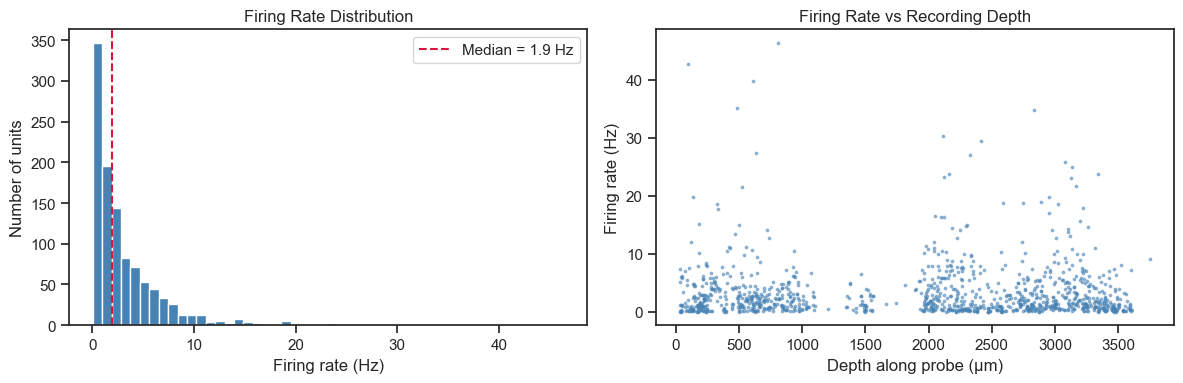


Plotting PSTH for unit 1062 (firing rate = 46.4 Hz)


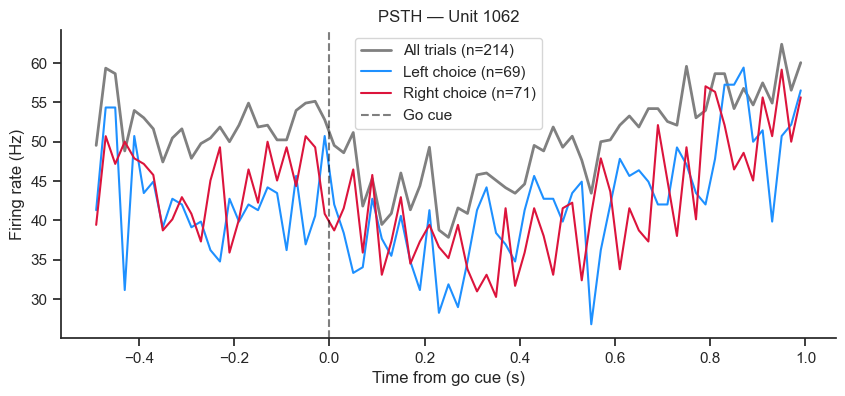

In [5]:
# ============================================================
# PRELIMINARY ANALYSIS
# ============================================================

# Check data shapes first
print("Data shapes:")
print(f"  spike_times:    {data['spike_times'].shape}")
print(f"  spike_clusters: {data['spike_clusters'].shape}")
print(f"  templates:      {data['templates'].shape}")
print(f"  channel_pos:    {data['channel_positions'].shape}")
print(f"  cluster_depths: {data['cluster_depths'].shape}")

# Ensure 1D arrays
spike_times = np.asarray(data["spike_times"]).ravel()
spike_clusters = np.asarray(data["spike_clusters"]).ravel().astype(int)
cluster_depths = np.asarray(data["cluster_depths"]).ravel()

# Recompute n_units from unique clusters
unique_clusters = np.unique(spike_clusters)
n_units = len(unique_clusters)
print(f"\nUnique clusters found: {n_units}")

# ----- 1. Basic summary stats -----
print("\n" + "=" * 60)
print("SESSION SUMMARY")
print("=" * 60)

total_spikes = len(spike_times)
print(f"Recording duration : {spike_times.max():.1f} s  "
      f"({spike_times.max()/60:.1f} min)")
print(f"Number of units    : {n_units}")
print(f"Total spikes       : {total_spikes:,}")
print(f"Mean firing rate   : {total_spikes / n_units / spike_times.max():.2f} Hz/unit")

# Firing rate per unit
spike_counts = np.bincount(spike_clusters, minlength=unique_clusters[-1]+1)
# Only take counts for units that exist
spike_counts = spike_counts[unique_clusters]
firing_rates = spike_counts / spike_times.max()
print(f"Median firing rate : {np.median(firing_rates):.2f} Hz")
print(f"Max firing rate    : {np.max(firing_rates):.2f} Hz")

# Trial statistics
trials = data["trial_info"]
n_trials = data["n_trials"]
choices = np.asarray(trials["response_choice"]).ravel()
left_pct  = 100 * np.sum(choices == -1) / n_trials
right_pct = 100 * np.sum(choices == 1) / n_trials
nogo_pct  = 100 * np.sum(choices == 0) / n_trials
print(f"\nTrial counts       : {n_trials}")
print(f"  Left choices     : {left_pct:.1f}%")
print(f"  Right choices    : {right_pct:.1f}%")
print(f"  No-go            : {nogo_pct:.1f}%")

# ----- 2. Firing rate distribution -----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(firing_rates, bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(np.median(firing_rates), color="crimson", ls="--", label=f"Median = {np.median(firing_rates):.1f} Hz")
axes[0].set_xlabel("Firing rate (Hz)")
axes[0].set_ylabel("Number of units")
axes[0].set_title("Firing Rate Distribution")
axes[0].legend()

# Depth vs firing rate
axes[1].scatter(cluster_depths, firing_rates, s=3, alpha=0.5, color="steelblue")
axes[1].set_xlabel("Depth along probe (µm)")
axes[1].set_ylabel("Firing rate (Hz)")
axes[1].set_title("Firing Rate vs Recording Depth")
plt.tight_layout()
plt.show()

# ----- 3. PSTH for an example unit -----
def get_unit_spike_times_alf(spike_clusters, spike_times, unit_id):
    """ALF-adapted spike time retrieval."""
    mask = spike_clusters == unit_id
    return spike_times[mask]


def compute_psth_alf(spike_clusters, spike_times, unit_id, align_times, bin_width=0.02, time_window=(-0.5, 1.0)):
    """PSTH aligned to given event times."""
    unit_spikes = get_unit_spike_times_alf(spike_clusters, spike_times, unit_id)
    bins = np.arange(time_window[0], time_window[1] + bin_width, bin_width)
    counts = np.zeros((len(align_times), len(bins) - 1))
    for i, t0 in enumerate(align_times):
        aligned = unit_spikes - t0
        in_window = (aligned >= time_window[0]) & (aligned < time_window[1])
        counts[i, :], _ = np.histogram(aligned[in_window], bins=bins)
    psth = counts.mean(axis=0) / bin_width
    t_centers = bins[:-1] + bin_width / 2
    return t_centers, psth


# Pick a high-firing unit for PSTH
best_unit = unique_clusters[np.argmax(firing_rates)]
print(f"\nPlotting PSTH for unit {best_unit} (firing rate = {firing_rates.max():.1f} Hz)")

# Split by choice (left vs right)
go_cue_times = np.asarray(trials["goCue_times"]).ravel()
choice_arr   = np.asarray(trials["response_choice"]).ravel()
left_mask  = choice_arr == -1
right_mask = choice_arr == 1

t_centers, psth_left  = compute_psth_alf(spike_clusters, spike_times, best_unit, go_cue_times[left_mask])
_,        psth_right  = compute_psth_alf(spike_clusters, spike_times, best_unit, go_cue_times[right_mask])
_,        psth_all    = compute_psth_alf(spike_clusters, spike_times, best_unit, go_cue_times)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_centers, psth_all,  color="grey",   lw=2, label=f"All trials (n={n_trials})")
ax.plot(t_centers, psth_left, color="dodgerblue", lw=1.5, label=f"Left choice (n={left_mask.sum()})")
ax.plot(t_centers, psth_right,color="crimson", lw=1.5, label=f"Right choice (n={right_mask.sum()})")
ax.axvline(0, color="black", ls="--", alpha=0.5, label="Go cue")
ax.set_xlabel("Time from go cue (s)")
ax.set_ylabel("Firing rate (Hz)")
ax.set_title(f"PSTH — Unit {best_unit}")
ax.legend()
sns.despine()
plt.show()

In [6]:
# ============================================================
# 4. CHOICE DECODING — Logistic Regression
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Use the raveled arrays from the analysis cell
# spike_clusters, spike_times, trials, unique_clusters

# Build a [trials × units] response matrix in the window 50–350 ms post go-cue
window = (0.05, 0.35)
go_times = np.asarray(trials["goCue_times"]).ravel()
choice_arr = np.asarray(trials["response_choice"]).ravel()

# Only left vs right trials (exclude no-go)
left_mask  = choice_arr == -1
right_mask = choice_arr == 1
mask = left_mask | right_mask

# Map unique clusters to contiguous indices for the matrix
cluster_to_idx = {c: i for i, c in enumerate(unique_clusters)}

X = np.zeros((mask.sum(), n_units))
for i, t0 in enumerate(go_times[mask]):
    aligned = spike_times - t0
    in_win = (aligned >= window[0]) & (aligned < window[1])
    clust_in_win = spike_clusters[in_win]
    for c in clust_in_win:
        X[i, cluster_to_idx[c]] += 1

y = np.where(right_mask[mask], 1, 0)  # 0=left, 1=right

print(f"\nDecoding left vs right from {window[0]:.2f}–{window[1]:.2f}s post go-cue")
print(f"  Trials: {X.shape[0]}  |  Units: {X.shape[1]}")
print(f"  Chance level: {max(np.mean(y), 1-np.mean(y))*100:.1f}%")

# Cross-validated logistic regression
clf = LogisticRegression(max_iter=5000, C=1.0, solver="liblinear")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y, cv=cv, scoring="accuracy")

print(f"\n  ✓ Stimulus window CV accuracy : {scores.mean()*100:.1f} ± {scores.std()*100:.1f} %")

# Baseline window for comparison
window_base = (-0.35, -0.05)
X_base = np.zeros((mask.sum(), n_units))
for i, t0 in enumerate(go_times[mask]):
    aligned = spike_times - t0
    in_win = (aligned >= window_base[0]) & (aligned < window_base[1])
    clust_in_win = spike_clusters[in_win]
    for c in clust_in_win:
        X_base[i, cluster_to_idx[c]] += 1

scores_base = cross_val_score(clf, X_base, y, cv=cv, scoring="accuracy")
print(f"  ✓ Baseline ({window_base[0]:.2f}–{window_base[1]:.2f}s) CV accuracy  : {scores_base.mean()*100:.1f} ± {scores_base.std()*100:.1f} %")

print("\n✓ Preliminary analysis complete.")


Decoding left vs right from 0.05–0.35s post go-cue
  Trials: 140  |  Units: 1085
  Chance level: 50.7%

  ✓ Stimulus window CV accuracy : 92.1 ± 4.2 %
  ✓ Baseline (-0.35–-0.05s) CV accuracy  : 87.1 ± 2.9 %

✓ Preliminary analysis complete.


Computing choice selectivity for all units...
Plotting raster for top 30 choice-modulated neurons...


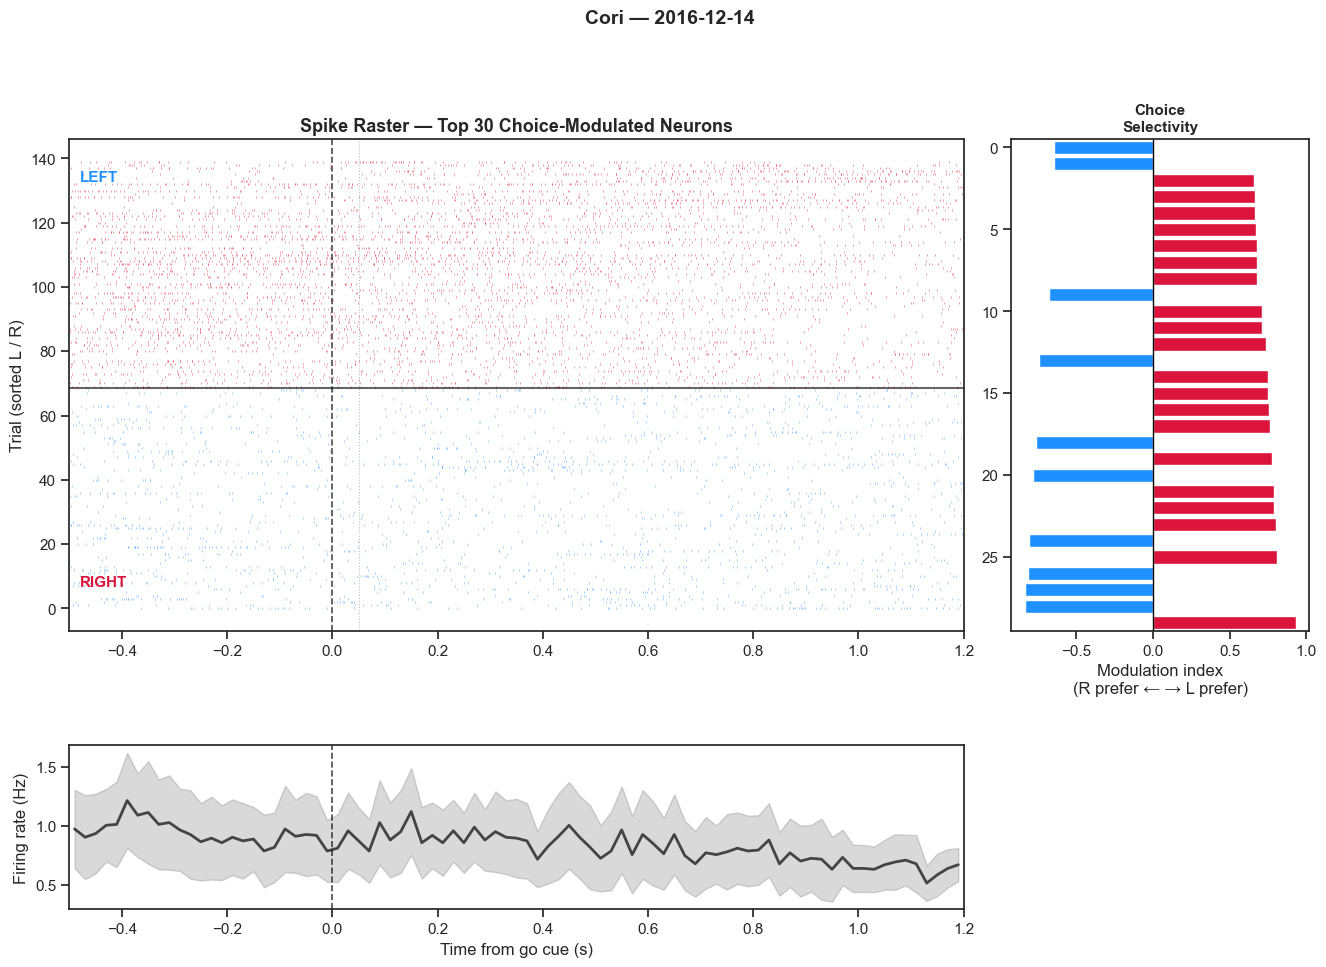

In [7]:
# ============================================================
# PROPER VISUALIZATIONS
# ============================================================
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


# ----- 1. SPIKE RASTER for top choice-selective neurons -----
print("Computing choice selectivity for all units...")

window_sel = (0.0, 0.4)  # post-go-cue window for selectivity
go_times = np.asarray(trials["goCue_times"]).ravel()
choice_arr = np.asarray(trials["response_choice"]).ravel()
left_mask = choice_arr == -1
right_mask = choice_arr == 1

# Compute left vs right firing rate per unit in the window
n_units = len(unique_clusters)
firing_left = np.zeros(n_units)
firing_right = np.zeros(n_units)
cluster_to_idx = {c: i for i, c in enumerate(unique_clusters)}

for i_trial, t0 in enumerate(go_times):
    aligned = spike_times - t0
    in_win = (aligned >= window_sel[0]) & (aligned < window_sel[1])
    clust_in_win = spike_clusters[in_win]
    for c in clust_in_win:
        idx = cluster_to_idx.get(c)
        if idx is not None:
            if choice_arr[i_trial] == -1:
                firing_left[idx] += 1
            elif choice_arr[i_trial] == 1:
                firing_right[idx] += 1

firing_left /= left_mask.sum()
firing_right /= right_mask.sum()
firing_left_hz = firing_left / (window_sel[1] - window_sel[0])
firing_right_hz = firing_right / (window_sel[1] - window_sel[0])

# Compute a modulation index: (R - L) / (R + L)
mod_idx = (firing_right_hz - firing_left_hz) / (firing_right_hz + firing_left_hz + 0.1)

# Pick top 30 most modulated neurons
n_show = 30
top_mod = np.argsort(np.abs(mod_idx))[-n_show:]

print(f"Plotting raster for top {n_show} choice-modulated neurons...")

# Build raster
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, width_ratios=[3, 1], height_ratios=[3, 1],
                      hspace=0.35, wspace=0.08)

ax_raster = fig.add_subplot(gs[0, 0])
ax_psth   = fig.add_subplot(gs[1, 0])
ax_select = fig.add_subplot(gs[0, 1])

colors_left_right = { -1: "dodgerblue", 1: "crimson" }
time_window = (-0.5, 1.2)

# Sort trials: left then right
left_trials_idx  = np.where(left_mask)[0]
right_trials_idx = np.where(right_mask)[0]
trial_order = np.concatenate([left_trials_idx, right_trials_idx])

# Plot raster
for row_i, unit in enumerate(top_mod):
    unit_spikes = spike_times[spike_clusters == unique_clusters[unit]]
    for trial_j, trial_idx in enumerate(trial_order):
        t0 = go_times[trial_idx]
        aligned = unit_spikes - t0
        in_win = (aligned >= time_window[0]) & (aligned < time_window[1])
        spikes_in = aligned[in_win]
        if len(spikes_in) > 0:
            color = colors_left_right[choice_arr[trial_idx]]
            ax_raster.scatter(spikes_in, np.full_like(spikes_in, trial_j),
                            s=2, c=color, marker="|", alpha=0.6, linewidths=0.5)

ax_raster.axvline(0, color="black", ls="--", lw=1.2, alpha=0.7)
ax_raster.axvline(0.05, color="grey", ls=":", lw=0.8, alpha=0.5)
ax_raster.axhline(len(left_trials_idx) - 0.5, color="black", ls="-", lw=1.5, alpha=0.6)
ax_raster.set_ylabel("Trial (sorted L / R)")
ax_raster.set_title(f"Spike Raster — Top {n_show} Choice-Modulated Neurons", fontsize=13, fontweight="bold")
ax_raster.text(time_window[0] + 0.02, len(trial_order) * 0.95, "LEFT", color="dodgerblue", fontsize=11, fontweight="bold")
ax_raster.text(time_window[0] + 0.02, len(left_trials_idx) * 0.1, "RIGHT", color="crimson", fontsize=11, fontweight="bold")
ax_raster.set_xlim(time_window)

# Population PSTH (average of these neurons)
all_psth_left = np.zeros((len(top_mod), 71))  # will compute properly
bin_width = 0.02
bins = np.arange(time_window[0], time_window[1] + bin_width, bin_width)
pop_psth = np.zeros((len(top_mod), len(bins)-1))
for row_i, unit in enumerate(top_mod):
    t_centers, pop_psth[row_i] = compute_psth_alf(spike_clusters, spike_times,
                                                   unique_clusters[unit], go_times,
                                                   bin_width=bin_width, time_window=time_window)

mean_psth = pop_psth.mean(axis=0)
sem_psth  = pop_psth.std(axis=0) / np.sqrt(len(top_mod))
t_centers = bins[:-1] + bin_width / 2

ax_psth.plot(t_centers, mean_psth, color="#444444", lw=2)
ax_psth.fill_between(t_centers, mean_psth - sem_psth, mean_psth + sem_psth,
                     color="#444444", alpha=0.2)
ax_psth.axvline(0, color="black", ls="--", lw=1.2, alpha=0.7)
ax_psth.set_xlabel("Time from go cue (s)")
ax_psth.set_ylabel("Firing rate (Hz)")
ax_psth.set_xlim(time_window)

# Selectivity barplot on the right
select_values = mod_idx[top_mod]
colors_bar = ["crimson" if v > 0 else "dodgerblue" for v in select_values]
ax_select.barh(range(n_show), select_values, color=colors_bar, edgecolor="white", height=0.8)
ax_select.axvline(0, color="black", ls="-", lw=1)
ax_select.set_xlabel("Modulation index\n(R prefer ← → L prefer)")
ax_select.set_title("Choice\nSelectivity", fontsize=11, fontweight="bold")
ax_select.set_ylim(-0.5, n_show - 0.5)
ax_select.invert_yaxis()

fig.suptitle(f"Cori — 2016-12-14", fontsize=14, fontweight="bold", y=1.01)
plt.show()


Plotting probe anatomy...


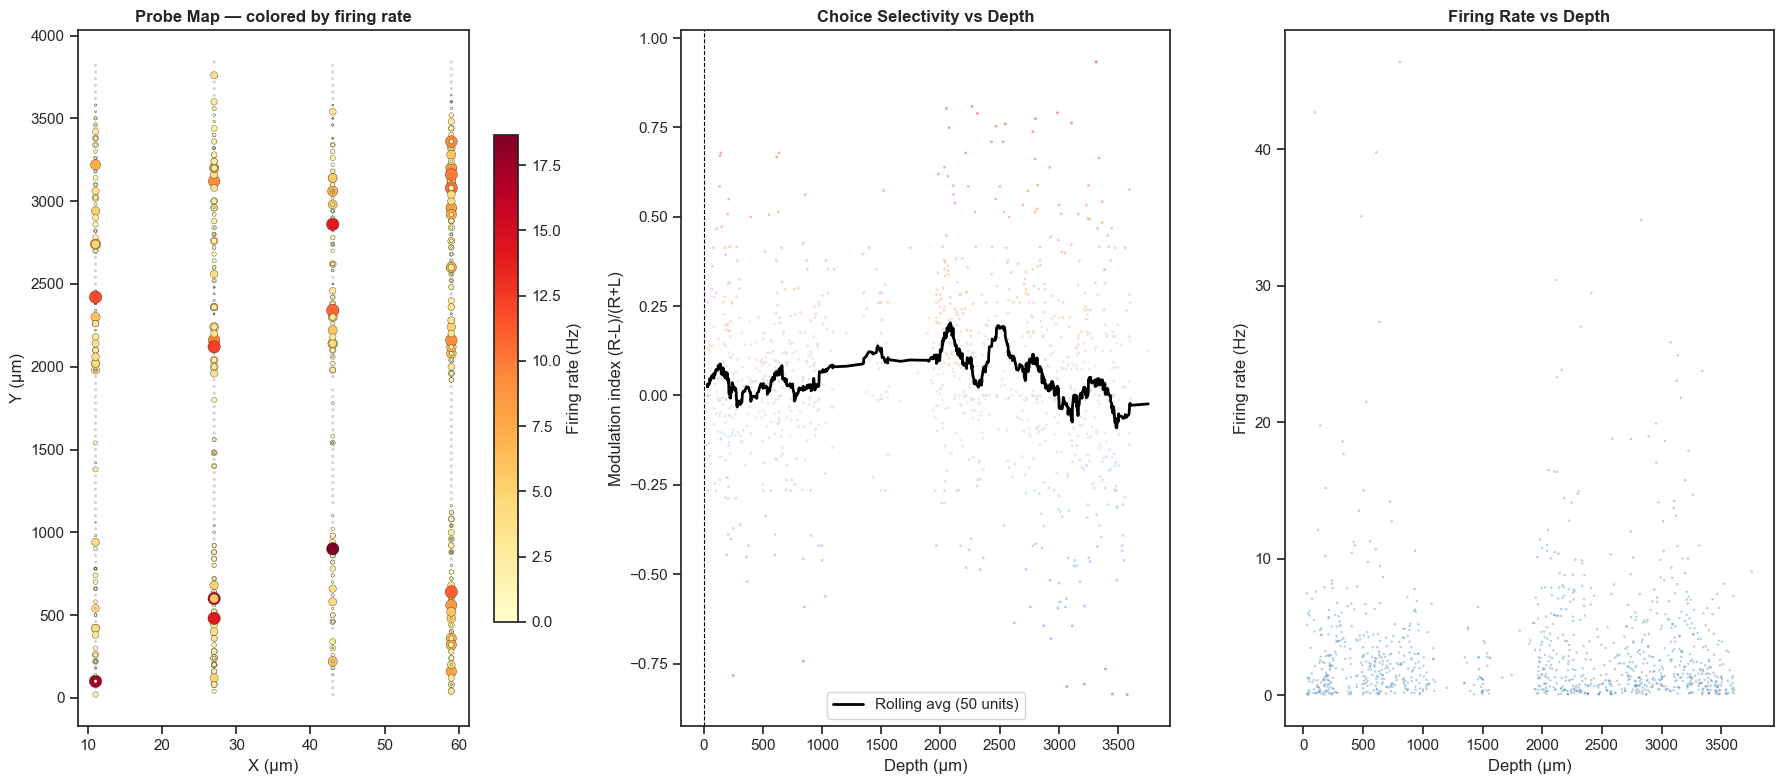

In [8]:
# ----- 2. PROBE ANATOMY MAP with selectivity overlay -----
print("\nPlotting probe anatomy...")

chan_pos = np.asarray(data["channel_positions"]).squeeze()
# Ensure 2D
if chan_pos.ndim == 1:
    chan_pos = chan_pos.reshape(-1, 2)

# cluster_depths and cluster_peakChannel tell us where each neuron is
cluster_depths = np.asarray(data["cluster_depths"]).ravel()
cluster_peak = np.asarray(data["cluster_peakChannel"]).ravel().astype(int)
cluster_probes = np.asarray(data["cluster_probes"]).ravel().astype(int)

# Get (x,y) for each neuron from its peak channel
neuron_x = chan_pos[cluster_peak, 0]
neuron_y = chan_pos[cluster_peak, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Panel 1: All channels
axes[0].scatter(chan_pos[:, 0], chan_pos[:, 1], s=4, c="lightgrey", edgecolors="none")
axes[0].scatter(neuron_x, neuron_y, s=np.clip(firing_rates * 3, 1, 80),
               c=firing_rates, cmap="YlOrRd", edgecolors="black", linewidths=0.2)
axes[0].set_xlabel("X (µm)")
axes[0].set_ylabel("Y (µm)")
axes[0].set_title("Probe Map — colored by firing rate", fontweight="bold")
plt.colorbar(ScalarMappable(norm=Normalize(0, np.percentile(firing_rates, 98)), cmap="YlOrRd"),
             ax=axes[0], label="Firing rate (Hz)", shrink=0.7)

# Panel 2: Choice selectivity across depth
axes[1].scatter(cluster_depths, mod_idx, s=4, c=mod_idx, cmap="coolwarm",
               vmin=-1, vmax=1, alpha=0.6, edgecolors="none")
axes[1].axvline(0, color="black", ls="--", lw=0.8)
axes[1].set_xlabel("Depth (µm)")
axes[1].set_ylabel("Modulation index (R-L)/(R+L)")
axes[1].set_title("Choice Selectivity vs Depth", fontweight="bold")

# Add a rolling average for trend
sort_idx = np.argsort(cluster_depths)
depths_sorted = cluster_depths[sort_idx]
mod_sorted = mod_idx[sort_idx]
window_size = 50
if len(mod_sorted) > window_size:
    roll_mean = np.convolve(mod_sorted, np.ones(window_size)/window_size, mode="same")
    axes[1].plot(depths_sorted, roll_mean, color="black", lw=2, label=f"Rolling avg ({window_size} units)")
    axes[1].legend()

# Panel 3: Firing rate vs depth
axes[2].scatter(cluster_depths, firing_rates, s=3, c="steelblue", alpha=0.4, edgecolors="none")
axes[2].set_xlabel("Depth (µm)")
axes[2].set_ylabel("Firing rate (Hz)")
axes[2].set_title("Firing Rate vs Depth", fontweight="bold")

plt.tight_layout()
plt.show()


Building population heatmap...


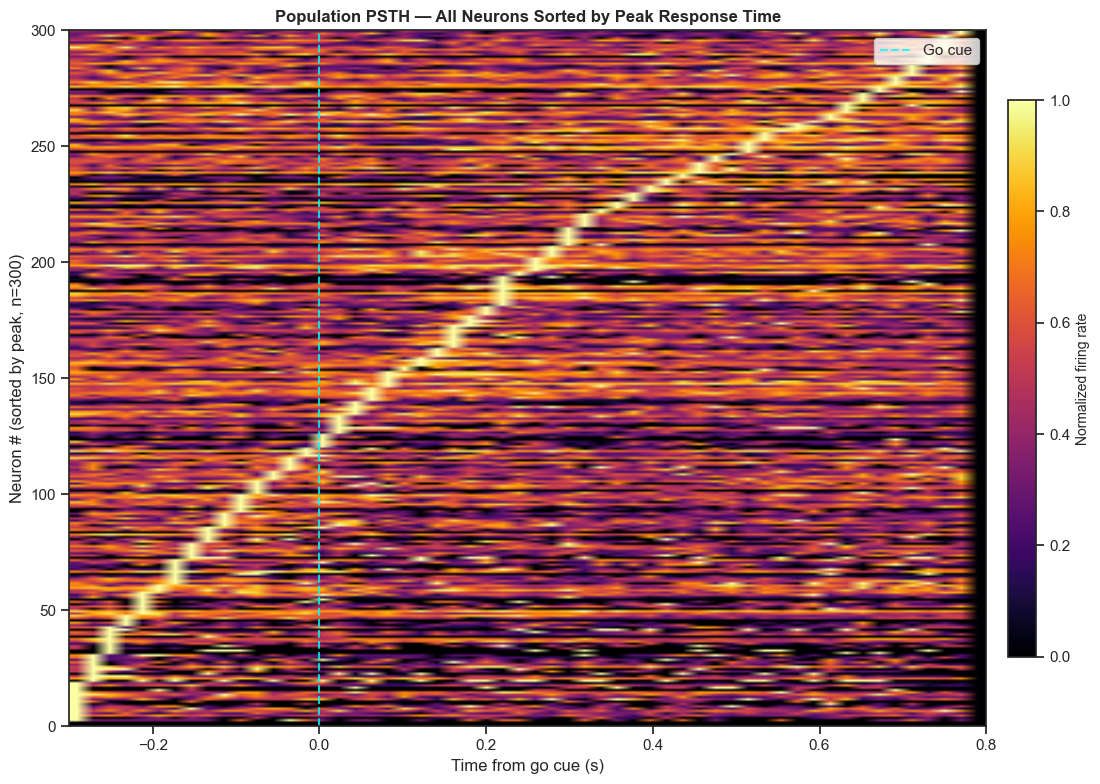

Population heatmap: 300 neurons, sorted by latency.


In [9]:
# ----- 3. POPULATION HEATMAP — all neurons sorted by peak response time -----
print("\nBuilding population heatmap...")

time_window_heat = (-0.3, 0.8)
bin_width = 0.02
bins_heat = np.arange(time_window_heat[0], time_window_heat[1] + bin_width, bin_width)
n_bins = len(bins_heat) - 1

# Sample a subset of neurons if there are too many (for speed)
n_sample = min(300, n_units)
sample_units = np.random.RandomState(42).choice(unique_clusters, n_sample, replace=False)

psth_matrix = np.zeros((n_sample, n_bins))
for i, uid in enumerate(sample_units):
    t_centers_heat, psth_matrix[i] = compute_psth_alf(
        spike_clusters, spike_times, uid, go_times,
        bin_width=bin_width, time_window=time_window_heat)

# Normalize each row to [0, 1]
psth_norm = psth_matrix - psth_matrix.min(axis=1, keepdims=True)
psth_norm /= psth_norm.max(axis=1, keepdims=True) + 1e-10

# Sort by peak response time
peak_bins = np.argmax(psth_norm, axis=1)
sort_order = np.argsort(peak_bins)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(psth_norm[sort_order], aspect="auto", origin="lower",
               extent=[time_window_heat[0], time_window_heat[1], 0, n_sample],
               cmap="inferno", interpolation="bilinear")

# Mark go cue
ax.axvline(0, color="cyan", ls="--", lw=1.5, alpha=0.8, label="Go cue")
ax.set_xlabel("Time from go cue (s)")
ax.set_ylabel(f"Neuron # (sorted by peak, n={n_sample})")
ax.set_title("Population PSTH — All Neurons Sorted by Peak Response Time", fontweight="bold")
ax.legend(loc="upper right")

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Normalized firing rate", fontsize=10)

plt.tight_layout()
plt.show()

print(f"Population heatmap: {n_sample} neurons, sorted by latency.")


Plotting behavioral data...


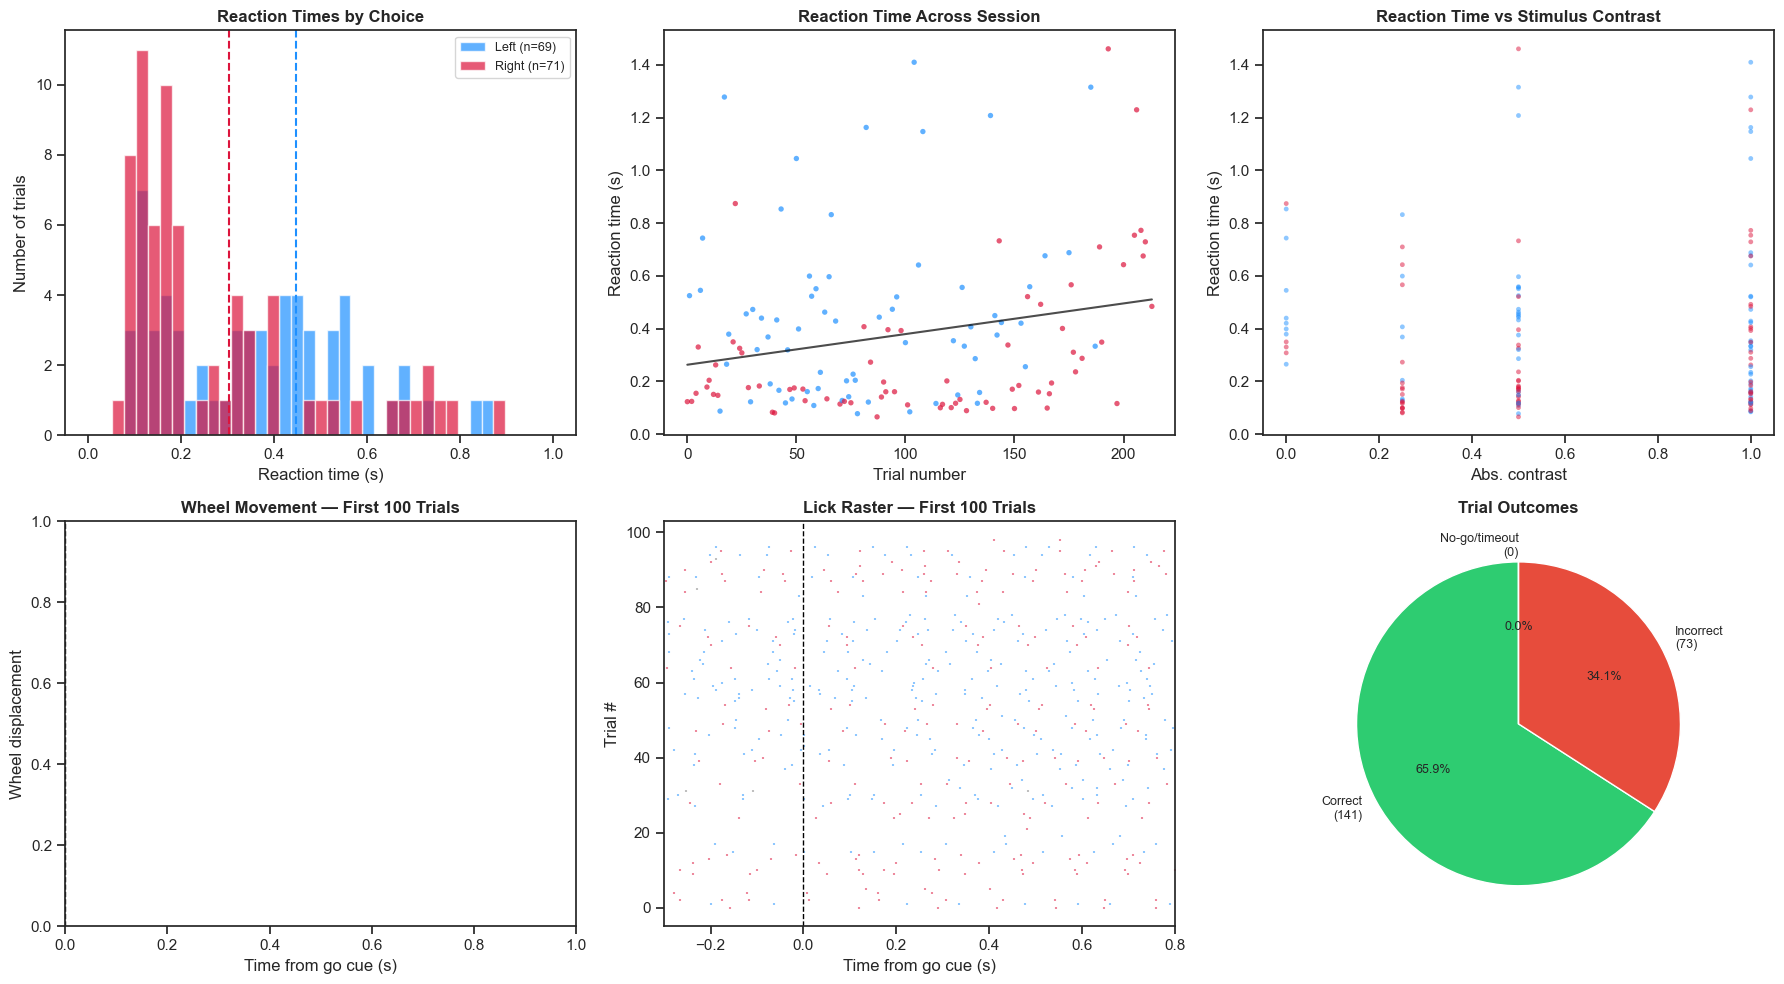

All visualizations complete.


In [10]:
# ----- 4. BEHAVIORAL VISUALIZATION: reaction times, wheel, licks -----
print("\nPlotting behavioral data...")

go_cue = np.asarray(trials["goCue_times"]).ravel()
response_times = np.asarray(trials["response_times"]).ravel()
feedback_times = np.asarray(trials["feedback_times"]).ravel()
contrast_left = np.asarray(trials["visualStim_contrastLeft"]).ravel()
contrast_right = np.asarray(trials["visualStim_contrastRight"]).ravel()
feedback_type = np.asarray(trials["feedbackType"]).ravel()  # -1 fail, 1 success

reaction_time = response_times - go_cue

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# A. Reaction time histogram by choice
ax = axes[0, 0]
bins_rt = np.linspace(0, 1.0, 40)
ax.hist(reaction_time[left_mask],  bins=bins_rt, color="dodgerblue", alpha=0.7, label=f"Left (n={left_mask.sum()})")
ax.hist(reaction_time[right_mask], bins=bins_rt, color="crimson", alpha=0.7, label=f"Right (n={right_mask.sum()})")
ax.axvline(reaction_time[left_mask].mean(), color="dodgerblue", ls="--", lw=1.5)
ax.axvline(reaction_time[right_mask].mean(), color="crimson", ls="--", lw=1.5)
ax.set_xlabel("Reaction time (s)")
ax.set_ylabel("Number of trials")
ax.set_title("Reaction Times by Choice", fontweight="bold")
ax.legend(fontsize=9)

# B. Reaction time vs trial number
ax = axes[0, 1]
trial_nums = np.arange(len(reaction_time))
colors_scatter = ["dodgerblue" if c == -1 else "crimson" if c == 1 else "grey" for c in choice_arr]
ax.scatter(trial_nums[left_mask|right_mask], reaction_time[left_mask|right_mask],
          c=np.array(colors_scatter)[left_mask|right_mask], s=15, alpha=0.7, edgecolors="none")
ax.set_xlabel("Trial number")
ax.set_ylabel("Reaction time (s)")
ax.set_title("Reaction Time Across Session", fontweight="bold")
# Add trend line
z = np.polyfit(trial_nums[left_mask|right_mask], reaction_time[left_mask|right_mask], 1)
p = np.poly1d(z)
ax.plot(trial_nums[left_mask|right_mask], p(trial_nums[left_mask|right_mask]), "black", lw=1.5, alpha=0.7)

# C. Contrast vs reaction time
ax = axes[0, 2]
valid_contrast = contrast_left + contrast_right
# Convert contrast to signed (+right, -left)
signed_contrast = np.where(contrast_right > 0, contrast_right, -contrast_left)
ax.scatter(np.abs(signed_contrast[left_mask|right_mask]), reaction_time[left_mask|right_mask],
          c=np.array(colors_scatter)[left_mask|right_mask], s=12, alpha=0.5, edgecolors="none")
ax.set_xlabel("Abs. contrast")
ax.set_ylabel("Reaction time (s)")
ax.set_title("Reaction Time vs Stimulus Contrast", fontweight="bold")

# D. Wheel movement (first 100 trials, aligned to go cue)
ax = axes[1, 0]
if "wheel.position" in data:
    wheel_pos = np.asarray(data["wheel.position"]).ravel()
    wheel_time = np.asarray(data["wheel.timestamps"]).ravel()
    tw = (-0.3, 0.8)
    n_trials_show = min(100, len(go_cue))
    wheel_traces = []
    for ti in range(n_trials_show):
        t0 = go_cue[ti]
        mask_w = (wheel_time >= t0 + tw[0]) & (wheel_time < t0 + tw[1])
        t_rel = wheel_time[mask_w] - t0
        if len(t_rel) > 0:
            # downsample for speed
            step = max(1, len(t_rel) // 200)
            color = "dodgerblue" if choice_arr[ti] == -1 else "crimson" if choice_arr[ti] == 1 else "grey"
            ax.plot(t_rel[::step], wheel_pos[mask_w][::step] - wheel_pos[mask_w][0],
                   color=color, alpha=0.15, lw=0.5)
    ax.axvline(0, color="black", ls="--", lw=1)
    ax.set_xlabel("Time from go cue (s)")
    ax.set_ylabel("Wheel displacement")
    ax.set_title(f"Wheel Movement — First {n_trials_show} Trials", fontweight="bold")

# E. Lick raster
ax = axes[1, 1]
if "licks.times" in data:
    lick_times = np.asarray(data["licks.times"]).ravel()
    n_trials_show = min(100, len(go_cue))
    tl = (-0.3, 0.8)
    for ti in range(n_trials_show):
        t0 = go_cue[ti]
        licks_in = lick_times[(lick_times >= t0 + tl[0]) & (lick_times < t0 + tl[1])] - t0
        color = "dodgerblue" if choice_arr[ti] == -1 else "crimson" if choice_arr[ti] == 1 else "grey"
        ax.scatter(licks_in, np.full_like(licks_in, ti), s=2, c=color, marker="|", alpha=0.5)
    ax.axvline(0, color="black", ls="--", lw=1)
    ax.set_xlabel("Time from go cue (s)")
    ax.set_ylabel("Trial #")
    ax.set_title(f"Lick Raster — First {n_trials_show} Trials", fontweight="bold")
    ax.set_xlim(tl)

# F. Outcome pie chart
ax = axes[1, 2]
correct = np.sum(feedback_type == 1)
incorrect = np.sum(feedback_type == -1)
# Trials where feedback is 0 (no feedback) — no-go or timeout
nogo_or_timeout = len(feedback_type) - correct - incorrect
wedges, texts, autotexts = ax.pie(
    [correct, incorrect, nogo_or_timeout],
    labels=[f"Correct\n({correct})", f"Incorrect\n({incorrect})", f"No-go/timeout\n({nogo_or_timeout})"],
    colors=["#2ecc71", "#e74c3c", "#bdc3c7"],
    autopct="%1.1f%%", startangle=90,
    textprops={"fontsize": 9}
)
ax.set_title("Trial Outcomes", fontweight="bold")

plt.tight_layout()
plt.show()

print("All visualizations complete.")

In [11]:
# ============================================================
# EXTRACT VISION-SPECIFIC NEURONS
# ============================================================

import pandas as pd


# ----- 1. Parse probe metadata to identify visual-cortex probe -----
probe_desc_path = Path(session_path) / "alf" / "probes.description.tsv"
probe_insert_path = Path(session_path) / "alf" / "probes.insertion.tsv"

df_desc = pd.read_csv(probe_desc_path, sep="\t")
df_insert = pd.read_csv(probe_insert_path, sep="\t")

print("Probe Insertion Coordinates:")
print(df_insert.to_string())

# Visual cortex in mouse is roughly AP < -3.0 mm (posterior to bregma)
# Probe 0 in Cori is at AP=1500µm (anterior: motor/SS), Probe 1 at AP=-4180µm (posterior: visual)
visual_probe_mask = df_insert["entry_point_ap"] < -3000
visual_probe_indices = np.where(visual_probe_mask)[0]

if len(visual_probe_indices) == 0:
    # Fallback: if no probe meets strict criteria, use the most posterior one
    visual_probe_indices = np.array([np.argmin(df_insert["entry_point_ap"].values)])
    print("WARNING: No probe with AP < -3.0mm found. Using most posterior probe.")

print(f"\nVisual probe(s) identified: {visual_probe_indices.tolist()}")
print(f"  AP coordinates: {df_insert['entry_point_ap'].values[visual_probe_indices]} µm")


# ----- 2. Map each neuron to its brain region -----
cluster_probes = np.asarray(data["cluster_probes"]).ravel().astype(int)

# Build per-probe brain-region labels from insertion data
# For this dataset, probes are in either visual or motor/frontal cortex
probe_to_region = {}
for i in range(len(df_insert)):
    ap = df_insert["entry_point_ap"].values[i]
    rl = df_insert["entry_point_rl"].values[i]
    if ap < -3000:
        # Posterior: visual areas
        probe_to_region[i] = "visual"
    elif ap > 0 and abs(rl) < 2000:
        # Anterior, near midline: motor/frontal
        probe_to_region[i] = "motor"
    else:
        probe_to_region[i] = "other"

print(f"\nProbe → Region mapping: {probe_to_region}")

# Assign each neuron to a region
neuron_region = np.array([probe_to_region.get(p, "unknown") for p in cluster_probes])

visual_neuron_mask = neuron_region == "visual"
motor_neuron_mask  = neuron_region == "motor"

n_visual = visual_neuron_mask.sum()
n_motor  = motor_neuron_mask.sum()
n_other  = (~visual_neuron_mask & ~motor_neuron_mask).sum()

print(f"\nNeuron breakdown by region:")
print(f"  Visual : {n_visual} neurons")
print(f"  Motor  : {n_motor} neurons")
print(f"  Other  : {n_other} neurons")


# ----- 3. Extract visual-neuron spike data -----
visual_unit_ids = unique_clusters[visual_neuron_mask]
motor_unit_ids  = unique_clusters[motor_neuron_mask]

# Fast spike-extraction for visual neurons
visual_spike_mask = np.isin(spike_clusters, visual_unit_ids)
motor_spike_mask  = np.isin(spike_clusters, motor_unit_ids)

visual_spike_times = spike_times[visual_spike_mask]
visual_spike_clusters = spike_clusters[visual_spike_mask]
motor_spike_times = spike_times[motor_spike_mask]
motor_spike_clusters = spike_clusters[motor_spike_mask]

print(f"\nVisual spikes : {len(visual_spike_times):,}")
print(f"Motor spikes  : {len(motor_spike_times):,}")


# ----- 4. Compare visual vs motor population responses -----
# PSTH for all visual neurons, split by contrast (left vs right stimulus)
print("\nComputing population PSTHs for visual vs motor neurons...")

time_window_comp = (-0.2, 0.6)
bin_width = 0.02
bins_comp = np.arange(time_window_comp[0], time_window_comp[1] + bin_width, bin_width)
n_bins_comp = len(bins_comp) - 1

contrast_left = np.asarray(trials["visualStim_contrastLeft"]).ravel()
contrast_right = np.asarray(trials["visualStim_contrastRight"]).ravel()
visual_stim_times = np.asarray(trials["visualStim_times"]).ravel()

# High-contrast left-only trials (visual stimulus in right hemifield)
stim_left_mask  = (contrast_left > 0.5) & (contrast_right == 0)
# High-contrast right-only trials (visual stimulus in left hemifield)
stim_right_mask = (contrast_right > 0.5) & (contrast_left == 0)


def compute_population_psth(spike_clust, spike_t, unit_ids_list, align_times,
                            bin_width=0.02, time_window=(-0.2, 0.6)):
    """
    Compute PSTH averaged across a population of neurons.
    Returns mean PSTH and SEM across neurons.
    """
    bins = np.arange(time_window[0], time_window[1] + bin_width, bin_width)
    n_bins = len(bins) - 1
    n_units_pop = len(unit_ids_list)
    psth_pop = np.zeros((n_units_pop, n_bins))

    for i, uid in enumerate(unit_ids_list):
        unit_spikes = spike_t[spike_clust == uid]
        counts_trials = np.zeros((len(align_times), n_bins))
        for j, t0 in enumerate(align_times):
            aligned = unit_spikes - t0
            in_win = (aligned >= time_window[0]) & (aligned < time_window[1])
            counts_trials[j, :], _ = np.histogram(aligned[in_win], bins=bins)
        psth_pop[i] = counts_trials.mean(axis=0) / bin_width

    t_centers = bins[:-1] + bin_width / 2
    mean_psth = psth_pop.mean(axis=0)
    sem_psth  = psth_pop.std(axis=0) / np.sqrt(n_units_pop)
    return t_centers, mean_psth, sem_psth


# Visual neuron PSTHs aligned to visual stimulus onset
stim_times_left  = visual_stim_times[stim_left_mask]
stim_times_right = visual_stim_times[stim_right_mask]

print(f"  Stimulus-left trials  : {stim_left_mask.sum()}")
print(f"  Stimulus-right trials : {stim_right_mask.sum()}")

t_vis, mean_vis_left, sem_vis_left   = compute_population_psth(
    visual_spike_clusters, visual_spike_times, visual_unit_ids,
    stim_times_left, bin_width=bin_width, time_window=time_window_comp)

_, mean_vis_right, sem_vis_right = compute_population_psth(
    visual_spike_clusters, visual_spike_times, visual_unit_ids,
    stim_times_right, bin_width=bin_width, time_window=time_window_comp)

# Motor neuron PSTHs (same alignment, for comparison)
t_mot, mean_mot_left, sem_mot_left   = compute_population_psth(
    motor_spike_clusters, motor_spike_times, motor_unit_ids,
    stim_times_left, bin_width=bin_width, time_window=time_window_comp)

_, mean_mot_right, sem_mot_right = compute_population_psth(
    motor_spike_clusters, motor_spike_times, motor_unit_ids,
    stim_times_right, bin_width=bin_width, time_window=time_window_comp)


# ----- 5. Build data structures for downstream analysis -----
# Pack vision-specific data into a clean dict
vision_data = {
    "unit_ids": visual_unit_ids,
    "n_units": n_visual,
    "spike_times": visual_spike_times,
    "spike_clusters": visual_spike_clusters,
    "firing_rates": firing_rates[visual_neuron_mask],
    "depths": cluster_depths[visual_neuron_mask],
    "mod_idx": mod_idx[visual_neuron_mask],
    "templates": data["templates"][visual_neuron_mask],
    "peak_channels": cluster_peak[visual_neuron_mask],
    # Population PSTHs (for later figures)
    "psth_stim_left": (t_vis, mean_vis_left, sem_vis_left),
    "psth_stim_right": (t_vis, mean_vis_right, sem_vis_right),
}

motor_data = {
    "unit_ids": motor_unit_ids,
    "n_units": n_motor,
    "spike_times": motor_spike_times,
    "spike_clusters": motor_spike_clusters,
    "firing_rates": firing_rates[motor_neuron_mask],
    "depths": cluster_depths[motor_neuron_mask],
    "mod_idx": mod_idx[motor_neuron_mask],
    # Population PSTHs
    "psth_stim_left": (t_mot, mean_mot_left, sem_mot_left),
    "psth_stim_right": (t_mot, mean_mot_right, sem_mot_right),
}

print(f"\n{'='*60}")
print(f"VISION DATA ready: {vision_data['n_units']} neurons, {len(vision_data['spike_times']):,} spikes")
print(f"MOTOR DATA ready:  {motor_data['n_units']} neurons, {len(motor_data['spike_times']):,} spikes")
print(f"{'='*60}")

Probe Insertion Coordinates:
   entry_point_rl  entry_point_ap  vertical_angle  horizontal_angle  axial_angle  distance_advanced
0            -640            1500       81.400131        172.959797            0               3800
1           -3180           -4180       74.096449        322.485452            0               3900

Visual probe(s) identified: [1]
  AP coordinates: [-4180] µm

Probe → Region mapping: {0: 'motor', 1: 'visual'}

Neuron breakdown by region:
  Visual : 534 neurons
  Motor  : 551 neurons
  Other  : 0 neurons

Visual spikes : 6,508,316
Motor spikes  : 3,509,160

Computing population PSTHs for visual vs motor neurons...
  Stimulus-left trials  : 18
  Stimulus-right trials : 21

VISION DATA ready: 534 neurons, 6,508,316 spikes
MOTOR DATA ready:  551 neurons, 3,509,160 spikes
